# Setup

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O
import sqlite3
import json

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/tmdb_5000_movies.csv
/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/tmdb_5000_credits.csv


In [2]:
# load TMDB datasets from Kaggle
movies_df = pd.read_csv('/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/tmdb_5000_movies.csv')
credits_df = pd.read_csv('/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/tmdb_5000_credits.csv')

# test that they were properly loaded
print(movies_df.columns)
print(credits_df.columns)
print()
print(movies_df.iloc[0])
print()
print(credits_df.iloc[0])

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')
Index(['movie_id', 'title', 'cast', 'crew'], dtype='object')

budget                                                          237000000
genres                  [{"id": 28, "name": "Action"}, {"id": 12, "nam...
homepage                                      http://www.avatarmovie.com/
id                                                                  19995
keywords                [{"id": 1463, "name": "culture clash"}, {"id":...
original_language                                                      en
original_title                                                     Avatar
overview                In the 22nd century, a paraplegic Marine is di...
popular

# Normalization

In [3]:
# function to transform JSON columns into a normalized tabular format
# each element in the JSON list becomes a separate row linked by movie_id
def normalize_json_column(df, column, movie_id_col='id'):
    records = []

    for _, row in df.iterrows():
        try:
            items = json.loads(row[column])
            for item in items:
                item['movie_id'] = row[movie_id_col]
                records.append(item)
        except:
            continue

    return pd.DataFrame(records)

In [4]:
# extract and normalize JSON columns into DataFrames
df_genres = normalize_json_column(movies_df, 'genres')
df_keywords = normalize_json_column(movies_df, 'keywords')
df_companies = normalize_json_column(movies_df, 'production_companies')
df_countries = normalize_json_column(movies_df, 'production_countries')
df_languages = normalize_json_column(movies_df, 'spoken_languages')

df_cast = normalize_json_column(credits_df, 'cast', movie_id_col='movie_id')
df_crew = normalize_json_column(credits_df, 'crew', movie_id_col='movie_id')

print(df_genres.head())

    id             name  movie_id
0   28           Action     19995
1   12        Adventure     19995
2   14          Fantasy     19995
3  878  Science Fiction     19995
4   12        Adventure       285


# Table Creation

In [5]:
# create main movies table with only atomic attributes (1NF)
movies = movies_df[[
    'id', 'title', 'original_title', 'original_language', 'overview',
    'release_date', 'budget', 'revenue', 'runtime', 'popularity',
    'vote_average', 'vote_count', 'status', 'homepage', 'tagline'
]].copy()

# rename primary key column for consistency across all tables
movies.rename(columns={'id': 'movie_id'}, inplace=True)


# GENRES

# create genres catalog table (removes redundancy and avoids indirect dependencies: 2NF + 3NF)
genres = df_genres[['id', 'name']].drop_duplicates()
genres.columns = ['genre_id', 'genre_name']

# create bridge table to represent many-to-many relationship between movies and genres (4NF)
movie_genres = df_genres[['movie_id', 'id']]
movie_genres.columns = ['movie_id', 'genre_id']


# KEYWORDS

# create keywords catalog table
keywords = df_keywords[['id', 'name']].drop_duplicates()
keywords.columns = ['keyword_id', 'keyword_name']

# bridge table linking movies and keywords
movie_keywords = df_keywords[['movie_id', 'id']]
movie_keywords.columns = ['movie_id', 'keyword_id']


# COMPANIES

# create production companies catalog table
companies = df_companies[['id', 'name']].drop_duplicates()
companies.columns = ['company_id', 'company_name']

# bridge table linking movies and production companies
movie_companies = df_companies[['movie_id', 'id']]
movie_companies.columns = ['movie_id', 'company_id']


# COUNTRIES

# create countries catalog table using ISO codes
# ensures country_name depends only on country_code (3NF)
countries = df_countries[['iso_3166_1', 'name']].drop_duplicates()
countries.columns = ['country_code', 'country_name']

# bridge table linking movies and countries
movie_countries = df_countries[['movie_id', 'iso_3166_1']]
movie_countries.columns = ['movie_id', 'country_code']


# LANGUAGES

# create languages catalog table using ISO codes
# separates language attributes to avoid transitive dependencies (3NF)
languages = df_languages[['iso_639_1', 'name']].drop_duplicates()
languages.columns = ['language_code', 'language_name']

# bridge table linking movies and languages
movie_languages = df_languages[['movie_id', 'iso_639_1']]
movie_languages.columns = ['movie_id', 'language_code']


# PEOPLE / CAST

# create people table to store unique actors (avoids repetition across movies)
people = df_cast[['id', 'name']].drop_duplicates()
people.columns = ['person_id', 'person_name']

# create movie_cast table including role-specific attributes (character and order)
# represents many-to-many relationship between movies and actors
movie_cast = df_cast[['movie_id', 'id', 'character', 'order']]
movie_cast.columns = ['movie_id', 'person_id', 'character_name', 'cast_order']

# Schema

In [6]:
# define SQL schema with primary keys and foreign key constraints
schema = """
PRAGMA foreign_keys = ON;

CREATE TABLE IF NOT EXISTS movies (
    movie_id INTEGER PRIMARY KEY,
    title TEXT,
    original_title TEXT,
    original_language TEXT,
    overview TEXT,
    release_date TEXT,
    budget INTEGER,
    revenue INTEGER,
    runtime REAL,
    popularity REAL,
    vote_average REAL,
    vote_count INTEGER,
    status TEXT,
    homepage TEXT,
    tagline TEXT
);

CREATE TABLE IF NOT EXISTS genres (
    genre_id INTEGER PRIMARY KEY,
    genre_name TEXT
);

CREATE TABLE IF NOT EXISTS movie_genres (
    movie_id INTEGER,
    genre_id INTEGER,
    FOREIGN KEY(movie_id) REFERENCES movies(movie_id),
    FOREIGN KEY(genre_id) REFERENCES genres(genre_id)
);

CREATE TABLE IF NOT EXISTS languages (
    language_code TEXT PRIMARY KEY,
    language_name TEXT
);

CREATE TABLE IF NOT EXISTS movie_languages (
    movie_id INTEGER,
    language_code TEXT,
    FOREIGN KEY(movie_id) REFERENCES movies(movie_id),
    FOREIGN KEY(language_code) REFERENCES languages(language_code)
);

CREATE TABLE IF NOT EXISTS people (
    person_id INTEGER PRIMARY KEY,
    person_name TEXT
);

CREATE TABLE IF NOT EXISTS movie_cast (
    movie_id INTEGER,
    person_id INTEGER,
    character_name TEXT,
    cast_order INTEGER,
    FOREIGN KEY(movie_id) REFERENCES movies(movie_id),
    FOREIGN KEY(person_id) REFERENCES people(person_id)
);

CREATE TABLE IF NOT EXISTS keywords (
    keyword_id INTEGER PRIMARY KEY,
    keyword_name TEXT
);

CREATE TABLE IF NOT EXISTS movie_keywords (
    movie_id INTEGER,
    keyword_id INTEGER,
    FOREIGN KEY(movie_id) REFERENCES movies(movie_id),
    FOREIGN KEY(keyword_id) REFERENCES keywords(keyword_id)
);

CREATE TABLE IF NOT EXISTS companies (
    company_id INTEGER PRIMARY KEY,
    company_name TEXT
);

CREATE TABLE IF NOT EXISTS movie_companies (
    movie_id INTEGER,
    company_id INTEGER,
    FOREIGN KEY(movie_id) REFERENCES movies(movie_id),
    FOREIGN KEY(company_id) REFERENCES companies(company_id)
);

CREATE TABLE IF NOT EXISTS countries (
    country_code TEXT PRIMARY KEY,
    country_name TEXT
);

CREATE TABLE IF NOT EXISTS movie_countries (
    movie_id INTEGER,
    country_code TEXT,
    FOREIGN KEY(movie_id) REFERENCES movies(movie_id),
    FOREIGN KEY(country_code) REFERENCES countries(country_code)
);


"""

In [7]:
# establish connection to SQLite database and create tables
conn = sqlite3.connect('/kaggle/working/tmdb.db')
cursor = conn.cursor()
cursor.executescript(schema)

# Load Data

In [8]:
# insert normalized DataFrames into SQL tables
movies.to_sql('movies', conn, if_exists='append', index=False)
genres.to_sql('genres', conn, if_exists='append', index=False)
movie_genres.to_sql('movie_genres', conn, if_exists='append', index=False)
languages.to_sql('languages', conn, if_exists='append', index=False)
movie_languages.to_sql('movie_languages', conn, if_exists='append', index=False)
people.to_sql('people', conn, if_exists='append', index=False)
movie_cast.to_sql('movie_cast', conn, if_exists='append', index=False)
keywords.to_sql('keywords', conn, if_exists='append', index=False)
movie_keywords.to_sql('movie_keywords', conn, if_exists='append', index=False)
companies.to_sql('companies', conn, if_exists='append', index=False)
movie_companies.to_sql('movie_companies', conn, if_exists='append', index=False)
countries.to_sql('countries', conn, if_exists='append', index=False)
movie_countries.to_sql('movie_countries', conn, if_exists='append', index=False)

conn.commit()

# Tests

In [9]:
# verify that tables were created and populated correctly
cursor = conn.cursor()

cursor.execute("""
SELECT name 
FROM sqlite_master 
WHERE type='table';
""")

tables = cursor.fetchall()
print("Tables in database:")
for t in tables:
    print(t)

Tables in database:
('movies',)
('genres',)
('movie_genres',)
('languages',)
('movie_languages',)
('people',)
('movie_cast',)
('keywords',)
('movie_keywords',)
('companies',)
('movie_companies',)
('countries',)
('movie_countries',)


In [10]:
tables = [
    'movies',
    'genres',
    'movie_genres',
    'languages',
    'movie_languages',
    'people',
    'movie_cast'
]

for table in tables:
    query = f"SELECT COUNT(*) FROM {table};"
    count = pd.read_sql_query(query, conn).iloc[0,0]
    print(f"{table}: {count} rows")

movies: 4803 rows
genres: 20 rows
movie_genres: 12160 rows
languages: 87 rows
movie_languages: 6937 rows
people: 54588 rows
movie_cast: 106257 rows


In [11]:
query = """
SELECT m.title, g.genre_name
FROM movies m
JOIN movie_genres mg ON m.movie_id = mg.movie_id
JOIN genres g ON mg.genre_id = g.genre_id
LIMIT 10;
"""

display(pd.read_sql_query(query, conn))

,title,genre_name
0,Avatar,Action
1,Avatar,Adventure
2,Avatar,Fantasy
3,Avatar,Science Fiction
4,Pirates of the Caribbean: At World's End,Adventure
5,Pirates of the Caribbean: At World's End,Fantasy
6,Pirates of the Caribbean: At World's End,Action
7,Spectre,Action
8,Spectre,Adventure
9,Spectre,Crime


In [12]:
query = """
SELECT m.title, p.person_name, mc.character_name
FROM movies m
JOIN movie_cast mc ON m.movie_id = mc.movie_id
JOIN people p ON mc.person_id = p.person_id
LIMIT 10;
"""

display(pd.read_sql_query(query, conn))

,title,person_name,character_name
0,Avatar,Sam Worthington,Jake Sully
1,Avatar,Zoe Saldana,Neytiri
2,Avatar,Sigourney Weaver,Dr. Grace Augustine
3,Avatar,Stephen Lang,Col. Quaritch
4,Avatar,Michelle Rodriguez,Trudy Chacon
5,Avatar,Giovanni Ribisi,Selfridge
6,Avatar,Joel David Moore,Norm Spellman
7,Avatar,CCH Pounder,Moat
8,Avatar,Wes Studi,Eytukan
9,Avatar,Laz Alonso,Tsu'Tey


In [13]:
query = """
SELECT m.title, l.language_name
FROM movies m
JOIN movie_languages ml ON m.movie_id = ml.movie_id
JOIN languages l ON ml.language_code = l.language_code
LIMIT 10;
"""

display(pd.read_sql_query(query, conn))

,title,language_name
0,Avatar,English
1,Avatar,Español
2,Pirates of the Caribbean: At World's End,English
3,Spectre,Français
4,Spectre,English
5,Spectre,Español
6,Spectre,Italiano
7,Spectre,Deutsch
8,The Dark Knight Rises,English
9,John Carter,English


# Queries

## Query 1: Keyword Search

In [14]:
# search movies by keyword and return relevant attributes
word = input("Enter keyword: ")

query = f"""
SELECT m.title,
       GROUP_CONCAT(DISTINCT g.genre_name),
       GROUP_CONCAT(DISTINCT l.language_name),
       m.popularity,
       GROUP_CONCAT(DISTINCT p.person_name)
FROM movies m
JOIN movie_keywords mk ON m.movie_id = mk.movie_id
JOIN keywords k ON mk.keyword_id = k.keyword_id
LEFT JOIN movie_genres mg ON m.movie_id = mg.movie_id
LEFT JOIN genres g ON mg.genre_id = g.genre_id
LEFT JOIN movie_languages ml ON m.movie_id = ml.movie_id
LEFT JOIN languages l ON ml.language_code = l.language_code
LEFT JOIN movie_cast mc ON m.movie_id = mc.movie_id
LEFT JOIN people p ON mc.person_id = p.person_id
WHERE k.keyword_name LIKE '%{word}%'
GROUP BY m.movie_id
LIMIT 15;
"""

df = pd.read_sql_query(query, conn)
display(df)

StdinNotImplementedError: raw_input was called, but this frontend does not support input requests.

## Query 2: Year Filter

In [ ]:
# filter movies by release year and sort results
year = input("Enter year: ")

query = f"""
SELECT title, release_date
FROM movies
WHERE SUBSTR(release_date,1,4) >= '{year}'
ORDER BY release_date ASC, title ASC
LIMIT 15;
"""

display(pd.read_sql_query(query, conn))

## Query 3: Genre Metrics

In [ ]:
# compute aggregated metrics by genre
query = """
SELECT g.genre_name,
       COUNT(*) as num_movies,
       AVG(m.vote_average) as avg_votes,
       AVG(m.popularity) as avg_popularity
FROM movie_genres mg
JOIN genres g ON mg.genre_id = g.genre_id
JOIN movies m ON mg.movie_id = m.movie_id
GROUP BY g.genre_name
HAVING avg_popularity >= 6
ORDER BY avg_popularity DESC
LIMIT 10;
"""

display(pd.read_sql_query(query, conn))

## Query 4: Year Metrics

In [ ]:
# compute aggregated metrics by year
query = """
SELECT SUBSTR(release_date,1,4) as year,
       COUNT(*) as num_movies,
       AVG(vote_average) as avg_votes,
       AVG(popularity) as avg_popularity
FROM movies
GROUP BY year
ORDER BY avg_popularity DESC;
"""

display(pd.read_sql_query(query, conn))

# Documentation

## Proceso de Normalización

Cuando analicé el dataset por primera vez, me di cuenta de que varias columnas no estaban en un formato adecuado para una base de datos relacional. Muchas de ellas (como genres, keywords, cast, etc.) estaban almacenadas como listas en formato JSON, lo que significa que había múltiples valores dentro de una sola columna. Por eso, fue necesario aplicar el proceso de normalización paso a paso antes de construir la base de datos.

### Primera Forma Normal (1NF)

El dataset violaba la 1NF porque algunas columnas contenían múltiples valores en forma de listas JSON en lugar de valores atómicos. Por ejemplo, una película podía tener varios géneros o varios actores dentro de una misma columna.

Para resolver esto, extraje esas columnas usando Python y convertí cada elemento de las listas en filas individuales dentro de nuevas tablas. Además, añadí un movie_id para poder mantener la relación con la película original.

Luego de este proceso, cada columna contiene valores individuales, por lo que se cumple la 1NF.

### Segunda Forma Normal (2NF)

Después de llevar los datos a 1NF, todavía había bastante redundancia. Por ejemplo, nombres de géneros o actores se repetían muchas veces a lo largo del dataset.

Para reducir esto, creé tablas separadas para entidades como géneros, keywords, lenguajes y personas. Luego utilicé tablas intermedias (como movie_genres y movie_cast) para relacionarlas con las películas.

De esta forma, cada tabla guarda solo un tipo de información y todos los atributos dependen completamente de su llave primaria, cumpliendo con la 2NF.

### Tercera Forma Normal (3NF)

Luego revisé si había dependencias indirectas entre los datos. Por ejemplo, el nombre de un lenguaje depende de su código, no directamente de la película.

Para evitar este tipo de dependencias, mantuve información como language_name o country_name en sus propias tablas en lugar de incluirlas directamente en la tabla de películas.

Esto elimina dependencias transitivas y permite cumplir con la 3NF.

### BCNF / Cuarta Forma Normal (4NF)

Finalmente, el dataset tiene múltiples relaciones independientes para cada película. Por ejemplo, una película puede tener varios géneros, varios actores y varios lenguajes, y estas relaciones no dependen entre sí.

Para manejar esto correctamente, creé tablas intermedias separadas para cada relación, como movie_genres, movie_languages y movie_cast.

Al separar estas relaciones, evito mezclar datos independientes y elimino dependencias multivaluadas, cumpliendo con BCNF y 4NF.

# Diagrams

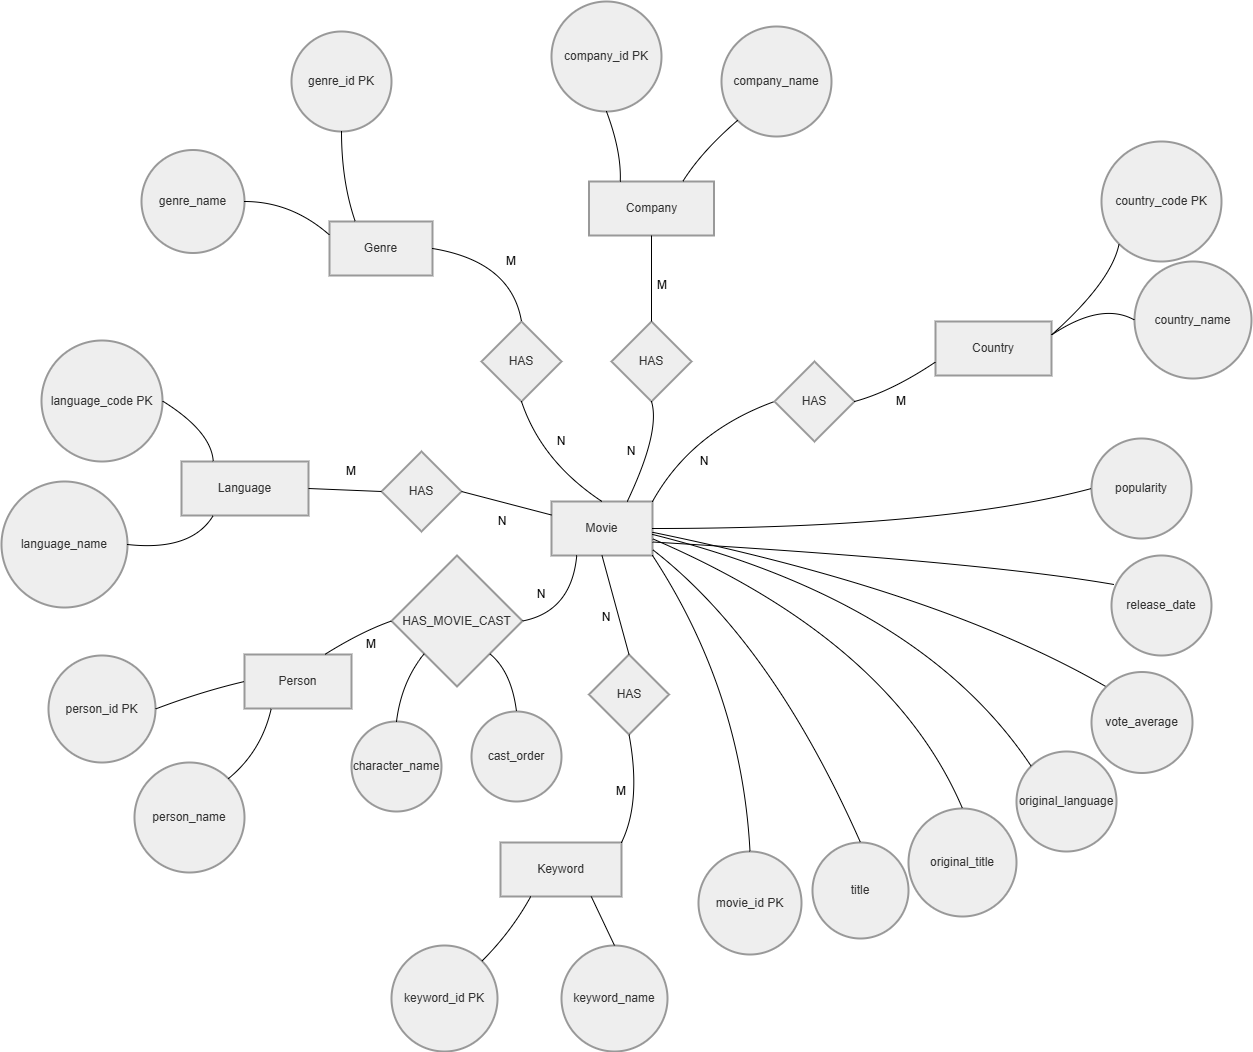

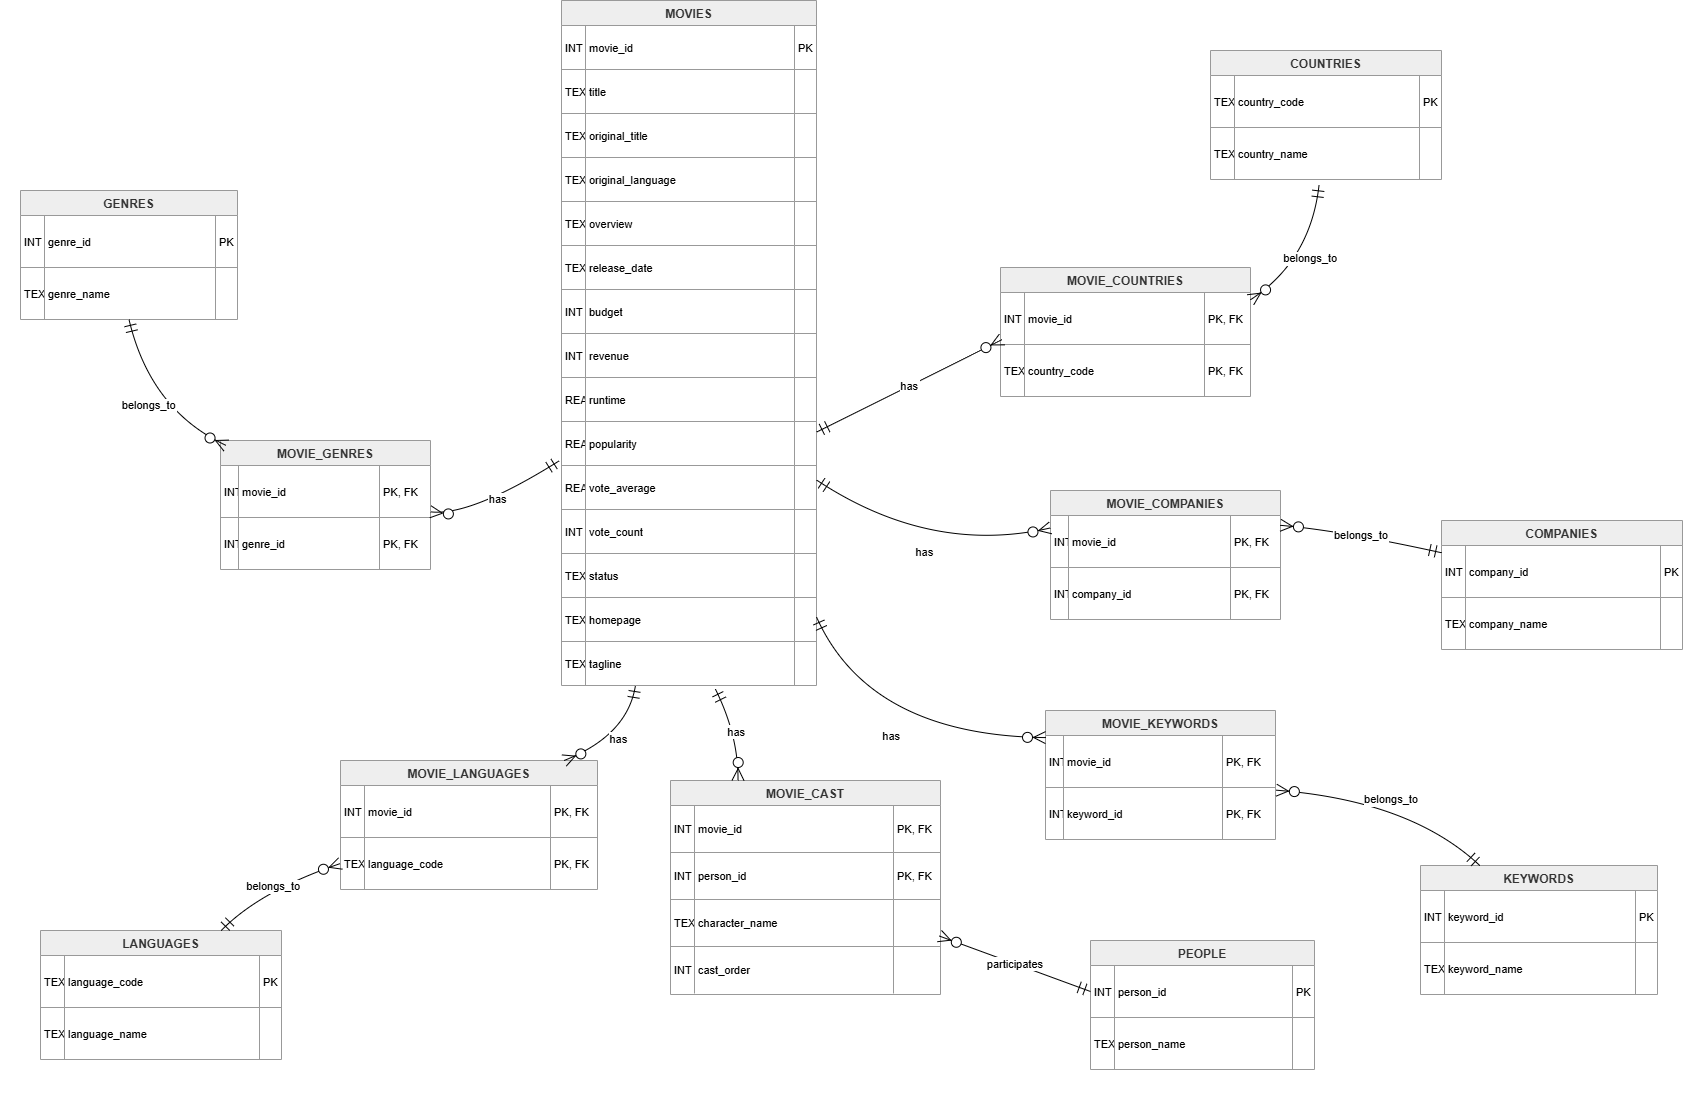